In [2]:
import copy
from   random import choice
import math 

import numpy as np
from   sklearn.cluster import HDBSCAN, DBSCAN
import hdbscan

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import NaiveDE
import SpatialDE
import pandas as pd

import networkx as nx

from plot import *
from data import *
from filt import *
from filt import ITNI, ITSNI, VNI

from scipy.optimize import minimize
from scipy.stats import nbinom


from matplotlib.patches import Circle
from matplotlib.lines import Line2D

import scanpy
from sklearn.neighbors import NearestNeighbors

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from collections import deque
from collections import defaultdict


In [3]:
#Definzione colori + grafica

W  = '#efefd0'
B  = '#004e89'
Or = "#ff6b35"
mpl.rcParams['text.color']       = B
mpl.rcParams['axes.labelcolor']  = B
mpl.rcParams['axes.edgecolor']   = B
mpl.rcParams['axes.facecolor']   = W
mpl.rcParams['figure.facecolor'] = W
mpl.rcParams['xtick.color']      = B
mpl.rcParams['ytick.color']      = B
mpl.rcParams['font.family']      = "monospace"

c1 = "#35cde2"
c2 = "#ab2b2b"

colors    = [B, Or]
cmap_name = "balck_yellow"
myCMAP    = LinearSegmentedColormap.from_list(cmap_name, colors)

mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 20,    
    "legend.fontsize": 14,
})

cmap_3 = ListedColormap([
    (0,0,0,0),  # 0 -> trasparente
    c1,         # 1 -> solo A
    c2,         # 2 -> solo B
    Or          # 3 -> A ∩ B
])

In [4]:
def plot_spatial_scatter(
        data, 
        gene_data, 
        ax           = None, 
        cmap         = CMAP, 
        figsize      = FIGSIZE, 
        spines_color = B,
        size         = None, 
        shape        = SHAPE,
        title = "",
        bottom_text=None,
        bottom_pad=-0.08):
    if not ax: 
        ax = plt.gca()
    
    data.obs["show_gene"] = gene_data
    sq.pl.spatial_scatter(
            data, 
            shape     = shape,
            color     = "show_gene", 
            figsize   = figsize,
            cmap      = cmap,
            colorbar  = COLORBAR,
            img_alpha = IMG_ALPHA,
            ax        = ax,
            size      = size
            )
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title(title)

    ax.spines['bottom'].set_color(spines_color)
    ax.spines['top'].set_color(spines_color)
    ax.spines['right'].set_color(spines_color)
    ax.spines['left'].set_color(spines_color)

    if bottom_text:
        ax.text(
            0.5, bottom_pad, bottom_text,
            transform=ax.transAxes,
            ha="center", va="top"
        )

In [5]:
scdata = load_data()
pgdata = np.load("trasnformed_gdata.npy")
df_meta = pd.read_csv("1.DLPFC/151673/metadata.tsv", sep='\t')
coords = df_meta[['imagecol', 'imagerow']].to_numpy(np.float32)
scdata.obsm['X_spatial'] = coords


original_gene_ids = np.load("transformed_gdata_gene_ids.npy")


/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
index_to_cart = np.zeros((len(scdata.obs), 2))
max_row       = scdata.obs['array_row'].max()
for i, ind in enumerate(scdata.obs.index):
    col = scdata.obs['array_col'][ind]
    row = scdata.obs['array_row'][ind]
    index_to_cart[i, 0] = col             * (np.sqrt(3)/2)
    index_to_cart[i, 1] = (max_row - row) * (3/2)

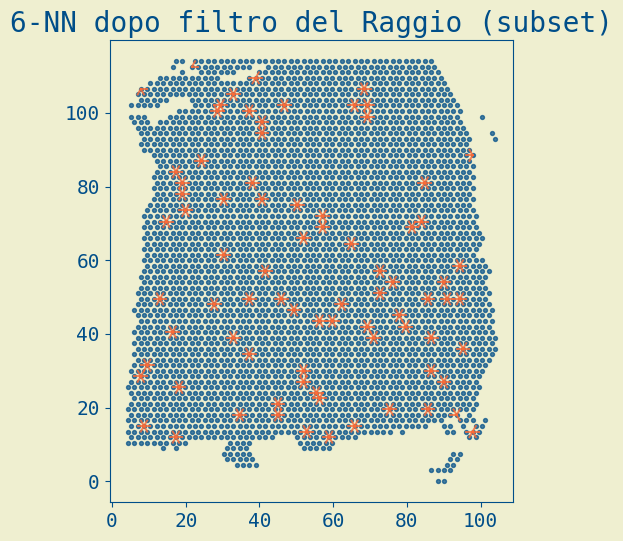

In [7]:
coords = index_to_cart  # shape: (n_spot, 2)
k = 1 + 6               # +1 perché include anche se stesso
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(coords)
dists, inds = nbrs.kneighbors(coords)

i = 0
vicini6 = inds[i, 1:]
distanze = dists[i, 1:]

# --- filtro per raggio ---
R = 1.74 

# liste di vicini/distanze filtrate per ogni nodo
vicini_filtrati  = []
distanze_filtrate = []

for i in range(len(coords)):
    di = dists[i, 1:]   # salta se stesso
    ii = inds[i, 1:]
    mask = di <= R      # "maggiore di R" viene rimosso
    vicini_filtrati.append(ii[mask])
    distanze_filtrate.append(di[mask])

np.random.seed(3)
sample = np.random.choice(len(coords), size=min(80, len(coords)), replace=False)

plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], s=8, alpha=0.7, facecolors=W, edgecolors=B, c=B)
for u in sample:
    for v in vicini_filtrati[u]:
        plt.plot([coords[u,0], coords[v,0]],
                 [coords[u,1], coords[v,1]],
                 lw=1.4, alpha=0.8,  color=Or)
plt.gca().set_aspect('equal'); plt.title('6-NN dopo filtro del Raggio (subset)')
plt.savefig("presentazioneCerinelli/SpotViciniFiltratiPerRaggio", dpi=1000)
plt.show()

In [8]:
binaryMasks = np.load("trasnformed_gdata.npy")  #tutte le binary mask dei 900 geni. 
number_of_genes = len(binaryMasks) 
number_of_spots = len(binaryMasks[0])
spat_var_genes = np.load("spatially_variable_genes.npy")
smallest   = select_top_spatially_variable_genes(scdata, 3000, 500, 3000)
gene_ids   = np.intersect1d(smallest, spat_var_genes)
gene_names = scdata.var.index.to_numpy()
array_data = scdata.X.toarray().T
subgenes = np.load("subgenes.npy", allow_pickle=True)
print("ciaoo")


ciaoo


In [9]:
binaryMasks = np.load("trasnformed_gdata.npy")  #tutte le binary mask dei 900 geni. 
                                                #mi dicono se nello spot 0 il gene è attivo o meno, 
                                                #se nello spot 1 il gene è attivo o meno ecc...

In [ ]:
def labels_from_two_masks(maskA, maskB):
    A = (np.asarray(maskA) == 1)
    B = (np.asarray(maskB) == 1)
    labels = np.zeros_like(A, dtype=int)   # 0 = nessuno
    labels[np.where(A & ~B)] = 1           # 1 = solo A
    labels[np.where(~A & B)] = 2           # 2 = solo B
    labels[np.where(A & B)]  = 3           # 3 = A ∩ B
    return labels

def mask_to_set(mask):
    maskArray = np.asarray(mask)
    return set(np.flatnonzero(maskArray == 1)) #Mi torno gli indici (gli spot) in cui il gene è attivo

def are_touching(A_set, B_set, neighbors):
    count = 0
    if not A_set or not B_set:
        return False
    # itera l’insieme più piccolo, li scambio se B > A
    if len(A_set) > len(B_set):
        A_set, B_set = B_set, A_set
    for i in A_set:
        # se qualunque vicino i di A_set sta in B_set -> toccano
        if any((j in B_set) for j in neighbors[i]):
            count+=1
        
    if(count>50): #se più di 50 spot di A toccano gli spot di B, li considero adiacenti
        return True
    return False

def classify_relation_soft(maskA, maskB, neighbors,contain_tol=0.02):   # contain tol = tolleranaza. qua 2%
    A = mask_to_set(maskA) #Binary mask 1
    B = mask_to_set(maskB) #Binary mask 2


    inter = A & B #intersezione. es: A = {1,3,4}, B = {2,3,5} -> inter = {3}
    overlapA = (len(inter) / len(A)) if A else 0.0 #Quanti spot di A sono in B in %
    overlapB = (len(inter) / len(B)) if B else 0.0 #Quanti spot di B sono in A in %

    missA = len(A - B)  # quanti spot di A restano fuori da B (dilatato)
    missB = len(B - A)  # viceversa

    if len(A) > 0 and (missA / len(A) <= contain_tol):
        return ("A contenuto in B (tollerato)",
                {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB,
                 "missA": missA, "tol": contain_tol})

    if len(B) > 0 and (missB / len(B) <= contain_tol):
        return ("B contenuto in A (tollerato)",
                {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB,
                 "missB": missB, "tol": contain_tol})

    # --- casi rimanenti ---
    if inter and (overlapA > 0.3) and (overlapB > 0.3):
        return ("Parzialmente sovrapposti (overlap senza contenimento)",
                {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB})

    if are_touching(A, B, neighbors) and (overlapA < 0.03) and (overlapB < 0.03):
        return ("Si toccano (adiacenti, poco overlap)",
                {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB})

    return ("Disgiunti (poco overlap e adiacenza)",
            {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB})

In [11]:
def index_subgenes(subgenes):
    """
    Crea due indici:
      - by_gene[gene_id] -> lista di entry (ordinata per sub_id)
      - by_pair[(gene_id, sub_id)] -> entry
    """
    by_gene = defaultdict(list)
    by_pair = {}
    for r in subgenes:
        by_gene[r["gene_id"]].append(r)
        by_pair[(r["gene_id"], r["sub_id"])] = r
    # ordina per sub_id per coerenza
    for gid in by_gene:
        by_gene[gid] = sorted(by_gene[gid], key=lambda r: r["sub_id"])
    return dict(by_gene), by_pair


In [13]:
by_gene, by_pair = index_subgenes(subgenes)

# tutte le entry del gene 8
g8_entries = by_gene.get(8, [])

# una entry specifica (gene 8, sub 1)
e_8_1 = by_pair.get((8, 1))   # dict con keys: gene_id, sub_id, count, comp_mask

In [14]:
def classify_subgene_pair(subgenes_by_pair, geneA, subA, geneB, subB, neighbors, contain_tol=0.01):
    """
    Confronta (geneA, subA) vs (geneB, subB) usando le comp_mask dei sotto-geni.
    Ritorna (label, info) come la tua classify_relation_soft.
    """
    eA = subgenes_by_pair.get((geneA, subA))
    eB = subgenes_by_pair.get((geneB, subB))
    if eA is None or eB is None:
        raise KeyError("Sottogene non trovato: controlla (gene_id, sub_id).")
    return classify_relation_soft(eA["comp_mask"], eB["comp_mask"], neighbors, contain_tol=contain_tol)


In [15]:
def labels_for_subgene_pair(subgenes_by_pair, geneA, subA, geneB, subB):
    eA = subgenes_by_pair[(geneA, subA)]
    eB = subgenes_by_pair[(geneB, subB)]
    return labels_from_two_masks(eA["comp_mask"], eB["comp_mask"])

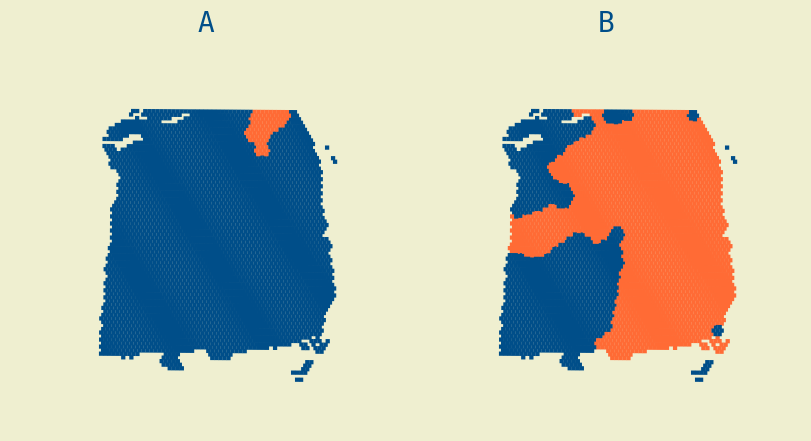

In [ ]:
mask0 = by_pair.get((0, 1))["comp_mask"]
mask1 = by_pair.get((14, 0))["comp_mask"]


A contenuto in B (tollerato) {'|A|': 86, '|B|': 2342, '|A∩B|': 85, 'overlapA': 0.9883720930232558, 'overlapB': 0.036293766011955594, 'missA': 1, 'tol': 0.02}


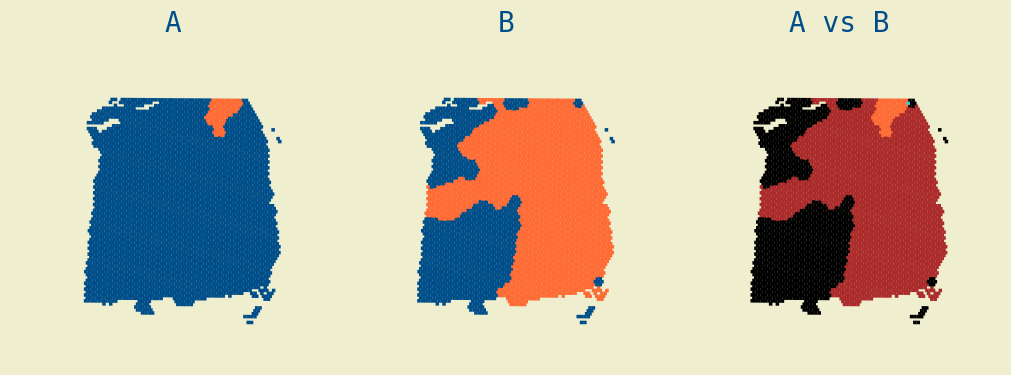

In [27]:
rel, info = classify_subgene_pair(by_pair, 0, 1, 14, 0, vicini_filtrati, contain_tol=0.02)
print(rel, info)

labels = labels_for_subgene_pair(by_pair, 0, 1, 14, 0)


fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(10, 5),
                                           gridspec_kw={"width_ratios":[1.2, 1.2,1.2]}, 
                                           constrained_layout=True)
array_data = scdata.X.toarray().T

plot_spatial_scatter(
    scdata, 
    mask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = "A",)

plot_spatial_scatter(
    scdata, 
    mask1, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = "B")


plot_spatial_scatter(
    scdata,
    labels,                 # array 0..3
    cmap         = cmap_3,  # colormap discreta
    spines_color = W,
    size         = 1.5,
    shape        = "square",
    ax           = ax3,
    title        = "A vs B",
)